In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Calculating acceleration and graphing

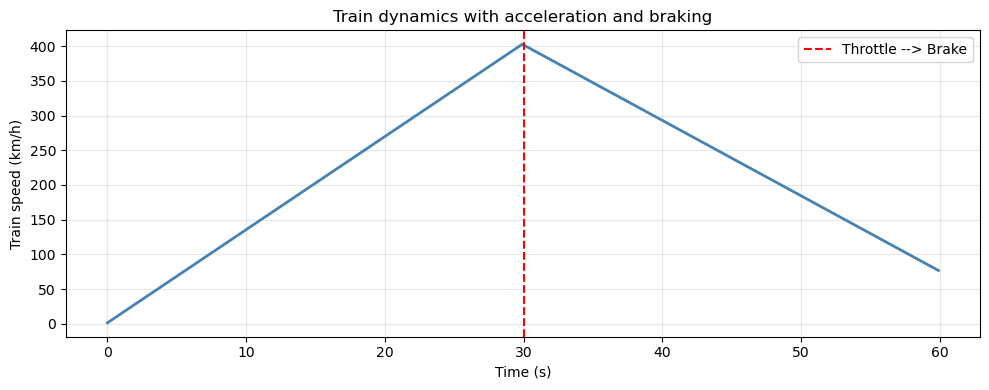

In [3]:
MASS = 4e4
MAX_TRACTION = 15e4
MAX_BRAKE = 12e4
ROLLING_RES = 2e-3
# seconds per timestep
DT = 0.1

def train_acceleration(v, throttle, brake, gradient_deg=0):

    #the component of the gravitational force which is parallel to the gradient
    f_slope = -MASS * 9.81 * np.sin(np.radians(gradient_deg))
    
    #force that comes from the brakes
    f_brake = -brake * MAX_BRAKE

    #the resistive force that comes from the tires of the train.
    f_rolling_res = -ROLLING_RES * MASS * 9.81

    f_traction = MAX_TRACTION * throttle

    f_net = f_slope + f_brake + f_rolling_res + f_traction

    #F_net = mass * acceleration
    return f_net / MASS

#60 seconds of simulation
steps = 600
#velocity of the train, initially zero
velocity = 0.0
#the speeds to be plotted
speeds = []

#divides the steps into equal parts, from 0 to 59.9, 0.0,0.1....
times = np.arange(steps) * DT

for i, t in enumerate(times):

    #train accelerates in the first 30 seconds then starts to use the brakes
    throttle = 1.0 if t < 30 else 0.0
    brake = 0.0 if t < 30 else 1.0

    a = train_acceleration(velocity, throttle, brake)
    
    #calculating the velocity from the formula: v_final = v_initial + a*t
    velocity = max(0.0, velocity + a * DT)

    # m/s -> km/h
    speeds.append(velocity * 3.6)

#size of the plot
plt.figure(figsize=(10,4))

#the x,y variables;line color and width
plt.plot(times, speeds, color="steelblue", linewidth=2)

#drawing the point the train starts decelearting
plt.axvline(30, color="red", linestyle="--", label="Throttle --> Brake")
plt.xlabel("Time (s)")
plt.ylabel("Train speed (km/h)")
plt.title("Train dynamics with acceleration and braking")

#showing the gridlines
plt.grid(True,alpha=0.3)

#
plt.legend()
plt.tight_layout()
plt.show()

### Graphing with different gradients

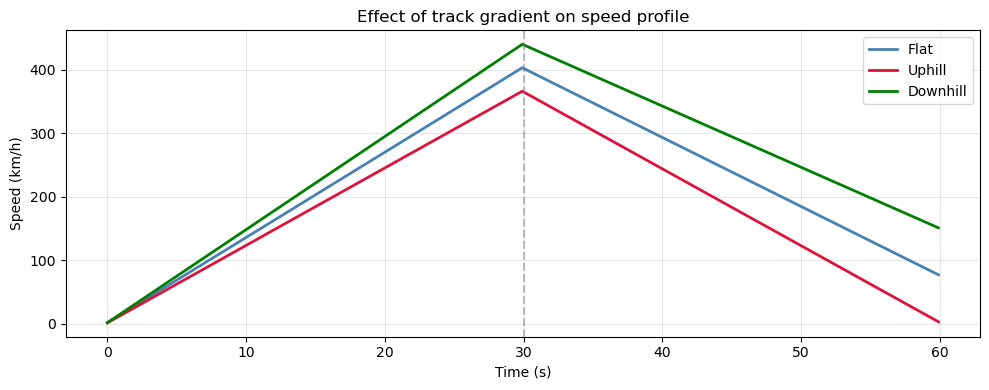

In [4]:
fig, ax = plt.subplots(figsize=(10,4))

for grad, label, color in [(0, "Flat", "steelblue"),
                           (2,"Uphill", "crimson"),
                           (-2,"Downhill","green")]:

    velocity = 0.0
    speeds = []

    for t in times:

        throttle = 1.0 if t < 30 else 0.0
        brake = 0.0 if t < 30 else 1.0

        a = train_acceleration(velocity, throttle, brake, grad)
        velocity = max(0.0, velocity + a * DT)
        speeds.append(velocity * 3.6)

    ax.plot(times, speeds, label=label, color=color, linewidth=2)

ax.axvline(30, color="gray", linestyle='--', alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Effect of track gradient on speed profile")
ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()
    


### Graphing position and velocity graphs

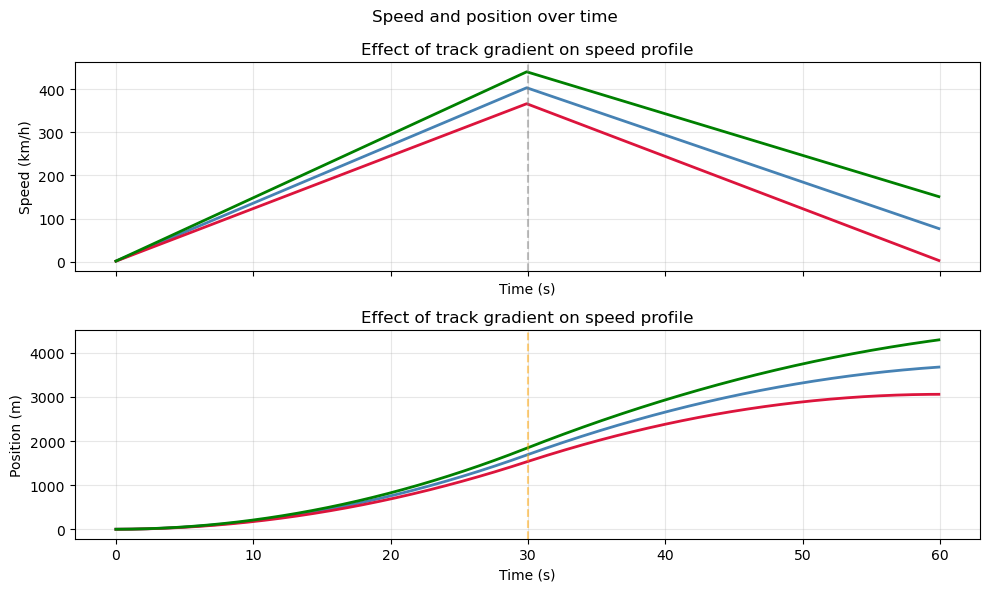

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for grad, label, color in [(0, "Flat", "steelblue"),
                           (2,"Uphill", "crimson"),
                           (-2,"Downhill","green")]:

    velocity = 0.0
    position = 0.0
    
    speeds, positions = [], []
    
    for t in times:
    
        throttle = 1.0 if t < 30 else 0.0
        brake = 0.0 if t < 30 else 1.0
    
        a = train_acceleration(velocity, throttle, brake, grad)
        
        velocity = max(0.0, velocity + a * DT)
        position = position + velocity * DT
        
        speeds.append(velocity * 3.6)
        positions.append(position)

    ax1.plot(times, speeds, label=label, color=color, linewidth=2)
    ax2.plot(times, positions, label=label, color=color, linewidth=2)

ax1.axvline(30, color="gray", linestyle='--', alpha=0.5)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Speed (km/h)")
ax1.set_title("Effect of track gradient on speed profile")
ax1.grid(True, alpha=0.3)

ax2.axvline(30, color="orange", linestyle='--', alpha=0.5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Position (m)")
ax2.set_title("Effect of track gradient on speed profile")
ax2.grid(True, alpha=0.3)

plt.suptitle("Speed and position over time")
plt.tight_layout()
plt.show()




### New Section